## Assignment Overview 
You are working as a Junior Business Analyst at a microfinance company in Nairobi. The company has shared a dataset of past loan applications and wants you to analyse it. Your job is to clean the data, explore it, create visualisations, and give business recommendations based on what you find.


## Section A: Data Loading & Data Inspection


 1.	Load the dataset and print the first 5 rows. What do you notice about the data? Write 2 observations.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv(r"C:\Users\HP\Desktop\Loan.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


Observation 1: The data contains loan applicants information where top five applicants are all male.

Observation 2: Applicant income and coaapliant income determines the loan amount

2.	Print the shape of the dataset. How many rows and columns does it have? What does each number represent in the context of this loan dataset?

In [5]:
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (614, 13)


##### the loan dataset has 614 rows and 13 columns

3.	Print the data types of all columns using df.dtypes or df.info(). List which columns are numeric and which are text (object). Why does this matter before doing any analysis?

In [6]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

Columns; Loan ID, Gender, Married, Dependents, Education, Self_Employed, Property_Area, Loan_Status are text
Columns; ApplicantIncome are numeric (whole numbrers)
Columns; CoapplicantIncome, LoanAmount, Loan_Amount_Term,Credit_History are numeric (Decimals)   
This is impotant before analysis so as to understand the kind of data you are analysing

4.	Use df.describe() to get summary statistics. 
Answer these questions in writing:     a) What is the average applicant income?     b) What is the highest loan amount requested? c) What is the average loan repayment term in months?


In [7]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


 a) average applicant income is 5403.459283
 b) highest loan amount requested is 700.000000	
 c)average loan repayment term in months is 342.00000

5.	Create a simple bar chart showing the count of loan approvals (Loan_Status = Y) vs rejections (Loan_Status = N). Add a title and axis labels. Write one sentence explaining what the chart tells you.

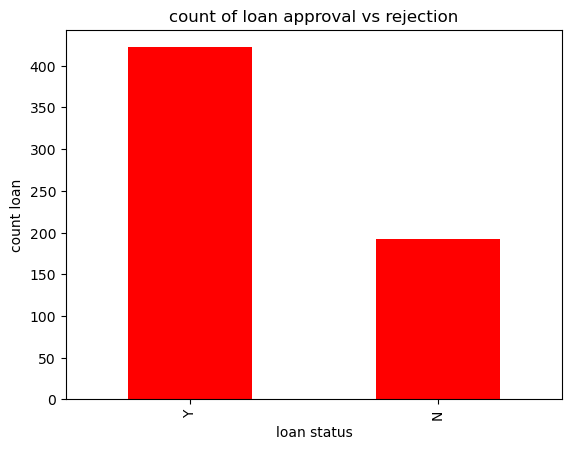

In [8]:
loan_counts=df["Loan_Status"].value_counts()
loan_counts.plot(kind="bar", color='red')
plt.title("count of loan approval vs rejection")
plt.xlabel("loan status")
plt.ylabel("count loan")
plt.show()

There are more loan approvals than rejections

## Section B: Cleaning & Missing Values

6.	Find all columns that have missing values. Print the count of missing values per column. Which column has the most missing values?

In [9]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)

Missing values per column:
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64


credit history has the most missing values

7.	Create a bar chart that shows the percentage of missing values for each column that has missing data. Write one business insight: what does this level of missing data mean for the company's data collection process?

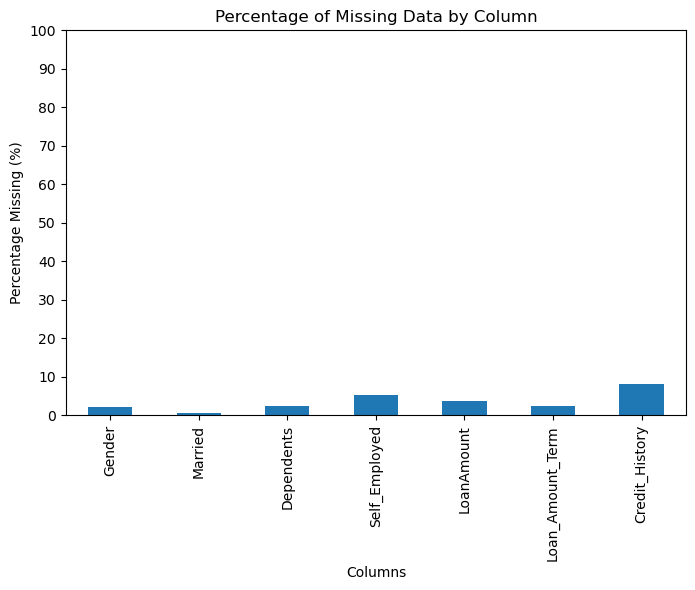

In [10]:
import matplotlib.pyplot as plt

percentage_missing_data = (df.isnull().sum() / len(df)) * 100
percentage_missing_data  = percentage_missing_data [percentage_missing_data  > 0]

plt.figure(figsize=(8,5))
percentage_missing_data.plot(kind='bar')
plt.title("Percentage of Missing Data by Column")
plt.xlabel("Columns")
plt.ylabel("Percentage Missing (%)")

plt.yticks(range(0, 101, 10))

plt.show()

it means that they should be careful while collecting data beacuse some like credit history, loan amount and loan amount term is sensitve and may impact the business negatively as they are values that cannot be filled as it directly affects loan approval.

8.	Handle the missing values using these strategies:     
a) Fill missing LoanAmount with the median loan amount    
b) Fill missing Loan_Amount_Term with the most common term (mode)    
c) Fill missing Gender, Married, Self_Employed and Dependents with 'Unknown'     
d) For Credit_History:  explain in writing why this column is trickier to fill and what you would recommend.


In [12]:
# a) Fill missing LoanAmount with median
df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())

# b) Fill missing Loan_Amount_Term with mode (most common value)
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])

# c) Fill missing categorical columns with 'Unknown'
df['Gender'] = df['Gender'].fillna('Unknown')
df['Married'] = df['Married'].fillna('Unknown')
df['Self_Employed'] = df['Self_Employed'].fillna('Unknown')
df['Dependents'] = df['Dependents'].fillna('Unknown')

In [15]:
## d) For Credit_History: explain in writing why this column is trickier to fill and what you would recommend.
df['Credit_History'] = df['Credit_History'].fillna('unknown')

Credit history indicates the clients history of repaying loans, defaulting loan payment not only affects the clients but also the business, i would recommend filling with unknown so as not to affect the accuracy loan approvals.

9.	 After cleaning, confirm that there are no more missing values by printing  df.isnull().sum() again. 

In [16]:
df.isnull().sum() 

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

## Section C: Exploratory Data Analysis & Visualizations

This is the core of EDA. Every question requires both the chart AND a written business insight. Think like an analyst

For every chart in this section, your written insight must follow this format:
•	What the chart shows
•	What it means for the business
•	One recommendation based on the finding


10.	Create a box plot of ApplicantIncome. Are there any outliers? What does a very high applicant income mean for the loan company? Should they remove those applicants from the data?

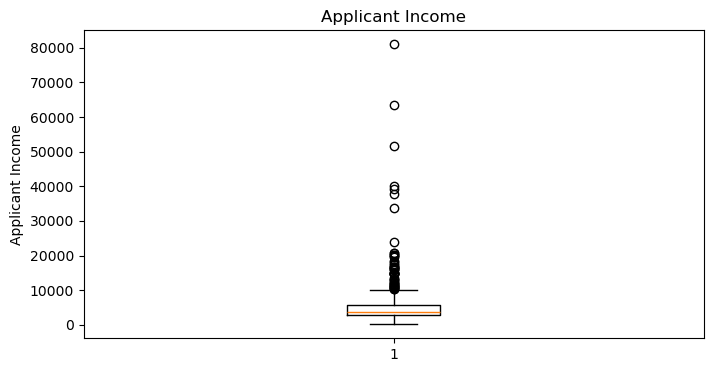

In [20]:
# Create box plot
plt.figure(figsize=(8,4))
plt.boxplot(df['ApplicantIncome'])
plt.title('Applicant Income')
plt.ylabel('Applicant Income')
plt.show()

having high income loan applicants means they ; have greater loan repayment ability comapred to low income applicants and they are not likely to default the loan, however it could also mean data entry error or unsusal cases, hence the data should be investigated first and only deleted if it is an error.

11.	Create a bar chart showing the total number of loan applications by Property_Area (Urban, Semiurban, Rural). Which area has the most applications? Write a business recommendation based on this.

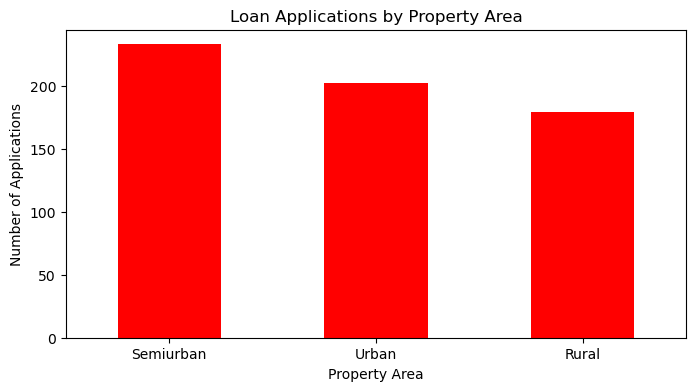

In [21]:
# Count loan applications by Property_Area
property_counts = df['Property_Area'].value_counts()

plt.figure(figsize=(8,4))
property_counts.plot(kind='bar', color='red')

plt.title('Loan Applications by Property Area')
plt.xlabel('Property Area')
plt.ylabel('Number of Applications')
plt.xticks(rotation=0)

plt.show()

semiurban areas has the most loan applicants, the institution should focus on marketing the business, introduce variety of loan produsts in the semiurban areas for higher customer reach and more loan approvals.

12.	Create a chart comparing loan approval rates (Loan_Status) for Graduates vs non-graduates. Does education level affect whether a loan gets approved? Write your insight.

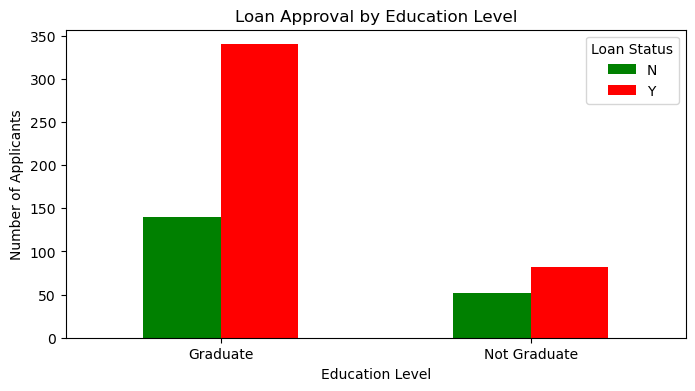

In [27]:
# Create approval counts by Education and Loan_Status
education_level = pd.crosstab(df['Education'], df['Loan_Status'])

education_level.plot(kind='bar', color=('green','red'), figsize=(8,4))

plt.title('Loan Approval by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)
plt.legend(title='Loan Status')

plt.show()

the chart suggest that garduates have a higher rate of loan approval compared to non gradutes which indicates that education level influnces loan approval decisoins .

13.	Create a histogram showing the distribution of LoanAmount. Describe the shape of the distribution : is it skewed? What does this tell you about the typical loan size most applicants request?

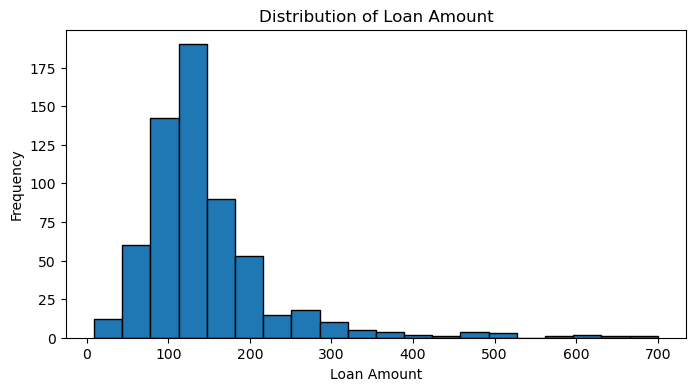

In [31]:
plt.figure(figsize=(8,4))
plt.hist(df['LoanAmount'], bins=20, edgecolor='black')

plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Frequency')

plt.show()

the histogram is skewed to the right meaning most loan applicants request for small to medium amounts compared to large amounts, meaning most applicants request relatively smaller or moderate loan amounts while a few applicants request very large loans. This indicates that the typical loan size requested is generally moderate, and high-value loan applications are less common.

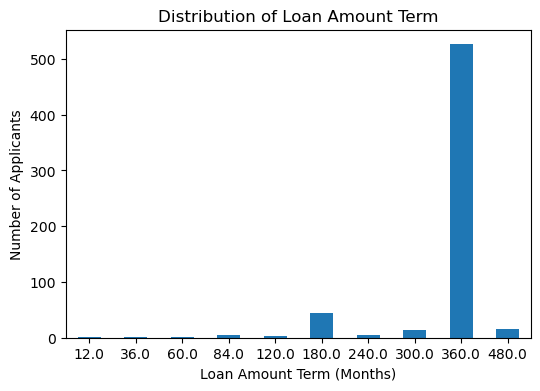

In [32]:
# Count loan term frequencies
loan_term_counts = df['Loan_Amount_Term'].value_counts().sort_index()

# Create bar chart
plt.figure(figsize=(6,4))
loan_term_counts.plot(kind='bar')

plt.title('Distribution of Loan Amount Term')
plt.xlabel('Loan Amount Term (Months)')
plt.ylabel('Number of Applicants')
plt.xticks(rotation=0)

plt.show()

I chose a bar chart because it clearly compares the number of applications across different loan repayment terms. The chart answers the business question of which repayment period customers prefer.360 months has the highest number of applications, suggesting most applicants prefer longer repayment periods, likely because it reduces monthly payment burden. The loan company may therefore prioritize and market long-term loan products while ensuring proper credit assessment.

Section D: Business Storytelling (15 marks) 

Write a short analyst report. (minimum 150 words) 
Summarize your findings from this dataset. Your report must include:     
a) 3 key findings from the data     
b) 2 recommendations for the loan company    
 c) 1 limitation of this dataset (what is missing that would make your analysis better?)  


##### This analysis examined loan application data to identify customer patterns, loan preferences, and factors related to loan approval outcomes.

###### key findings

1. Loan amounts tend to be positively skewed, meaning most applicants request small to moderate loan amounts while only a few apply for very large loans. This suggests that the typical customer seeks manageable loan sizes rather than extremely high-value borrowing.

2. Loan repayment terms. The analysis of Loan_Amount_Term showed that longer repayment periods, particularly 360-month loans, appear to be the most common among applicants. This indicates that customers generally prefer longer repayment periods, likely because they reduce monthly payment pressure.

3. Education and loan approval status. Graduates appeared to have slightly higher approval rates compared to non-graduates, although education alone may not fully determine approval outcomes. Other variables such as credit history and income likely play an important role.

###### Recomendation
The company should continue offering and promoting long-term loan products because customer demand appears strongest for these repayment options.

One limitation of this dataset is the lack of detailed financial information such as debt levels,repayment history. Including these variables would improve the accuracy and depth of loan approval and risk analysis.
